In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to work dir
# to import my modules
dir_work ='/nfs/home/svu/e1498138/localgit/FEWNEW/work/'

os.chdir(dir_work)
sys.path.insert(0, dir_work)

import GWfuncs
import loglike_timemax_T  # TIME-MAXIMIZED VERSION, with T as param
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 2     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax_T.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")

def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0, T_prop = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, 
                                            dist, qS, phiS, qK, phiK, 
                                            Phi_phi0, Phi_theta0, Phi_r0,
                                            T_prop]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    Tlim = [3/12,2]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    # T
    transformed[:, 5] = (Tlim[1] - Tlim[0]) * u[:, 5] + Tlim[0]


    return transformed

def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    Tlim = [3/12,2]

    params = np.asarray(params)
    u = np.zeros_like(params)

    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - Tlim[0]) / (Tlim[1] - Tlim[0])                                                                                                                                                 

    return u



print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 2 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 32.86622400746991
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
dir_scratch='/scratch/e1498138/'
savepath = dir_scratch+'paris2/int_3mth_snr32_dur_anneal2'


In [4]:
def custom_terminate_condition(sampler, proc_idx):
    """
    Terminate a process if:
    1. Its max_logden has been stable for > 1000 iterations, AND
    2. Its best log-density lags more than 'gap' below the global best
       (meaning it is stuck in a low-likelihood region).
    """
    stable_count = sampler._proc_max_ld_stable_count[proc_idx]

    if stable_count > 1000:
        global_best = max(sampler.max_logden_list)
        proc_best   = sampler.max_logden_list[proc_idx]
        gap = 50.0  # tune: SNR^2/2 units; 50 ≈ large mismatch

        if proc_best < global_best - gap:
            print(
                f"\n[Terminator] Process {proc_idx} terminated: "
                f"stable {stable_count} iters, "
                f"proc_best={proc_best:.2f} vs global_best={global_best:.2f} "
                f"(gap={global_best - proc_best:.2f})",
                flush=True,
            )
            return True

    return False

In [5]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [6]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [7]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 4.31453000e-01,  2.16993000e-01,  3.03237000e-01,
          4.86693000e-01,  7.99663000e-01,  0.00000000e+00],
        [ 4.31440653e-01,  2.16995660e-01,  3.03226226e-01,
          4.86698440e-01,  7.99673128e-01, -2.16782458e-06],
        [ 4.31447981e-01,  2.16988467e-01,  3.03231968e-01,
          4.86681506e-01,  7.99667403e-01,  7.14595498e-06],
        ...,
        [ 3.80098300e-01,  3.65946740e-01,  2.07207381e-01,
          5.13859713e-01,  5.73729199e-01,  1.31623933e-01],
        [ 2.91855999e-01,  3.46794084e-01,  3.09484803e-03,
          7.60928211e-01,  6.16427836e-01, -4.28284558e-03],
        [ 3.67198920e-01,  3.03300358e-01,  2.52020786e-01,
          4.48853095e-01,  6.11764708e-01,  7.40974361e-02]],
       shape=(10000, 6)),
 array([[ 6.08307000e-01,  7.40431000e-01,  7.00827000e-01,
          1.77909000e-01,  2.35619000e-01,  0.00000000e+00],
        [ 6.08307976e-01,  7.40432650e-01,  7.00831046e-01,
          1.77904491e-01,  2.35628376e-01, -4.9801067

In [8]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([1.79834691,       -inf, 5.67135894, ..., 1.02480763,       -inf,
        0.78450251], shape=(10000,)),
 array([1.61606305,       -inf,       -inf, ...,       -inf,       -inf,
              -inf], shape=(10000,))]

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.86094973, 0.94932914, 0.37423295, 9.58905805, 0.37872334,
        0.26173524]])

In [14]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[ 6.26796664e+00,  7.97990215e-01,  3.01750019e-01,
         9.08393420e+00,  3.89485361e-01, -7.08865475e-03]])

In [15]:
log_density(maxld_pt1), log_density(maxld_pt2)

(array([5.65692324]), array([-inf]))

In [16]:
log_density([param_true])

array([32.33698013])

In [11]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                (3/12,2)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5), (0.25, 2)]

In [12]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,T]
param_true

[np.float64(6.0), np.float64(1.0), 0.7, 9, 0.4, 2]

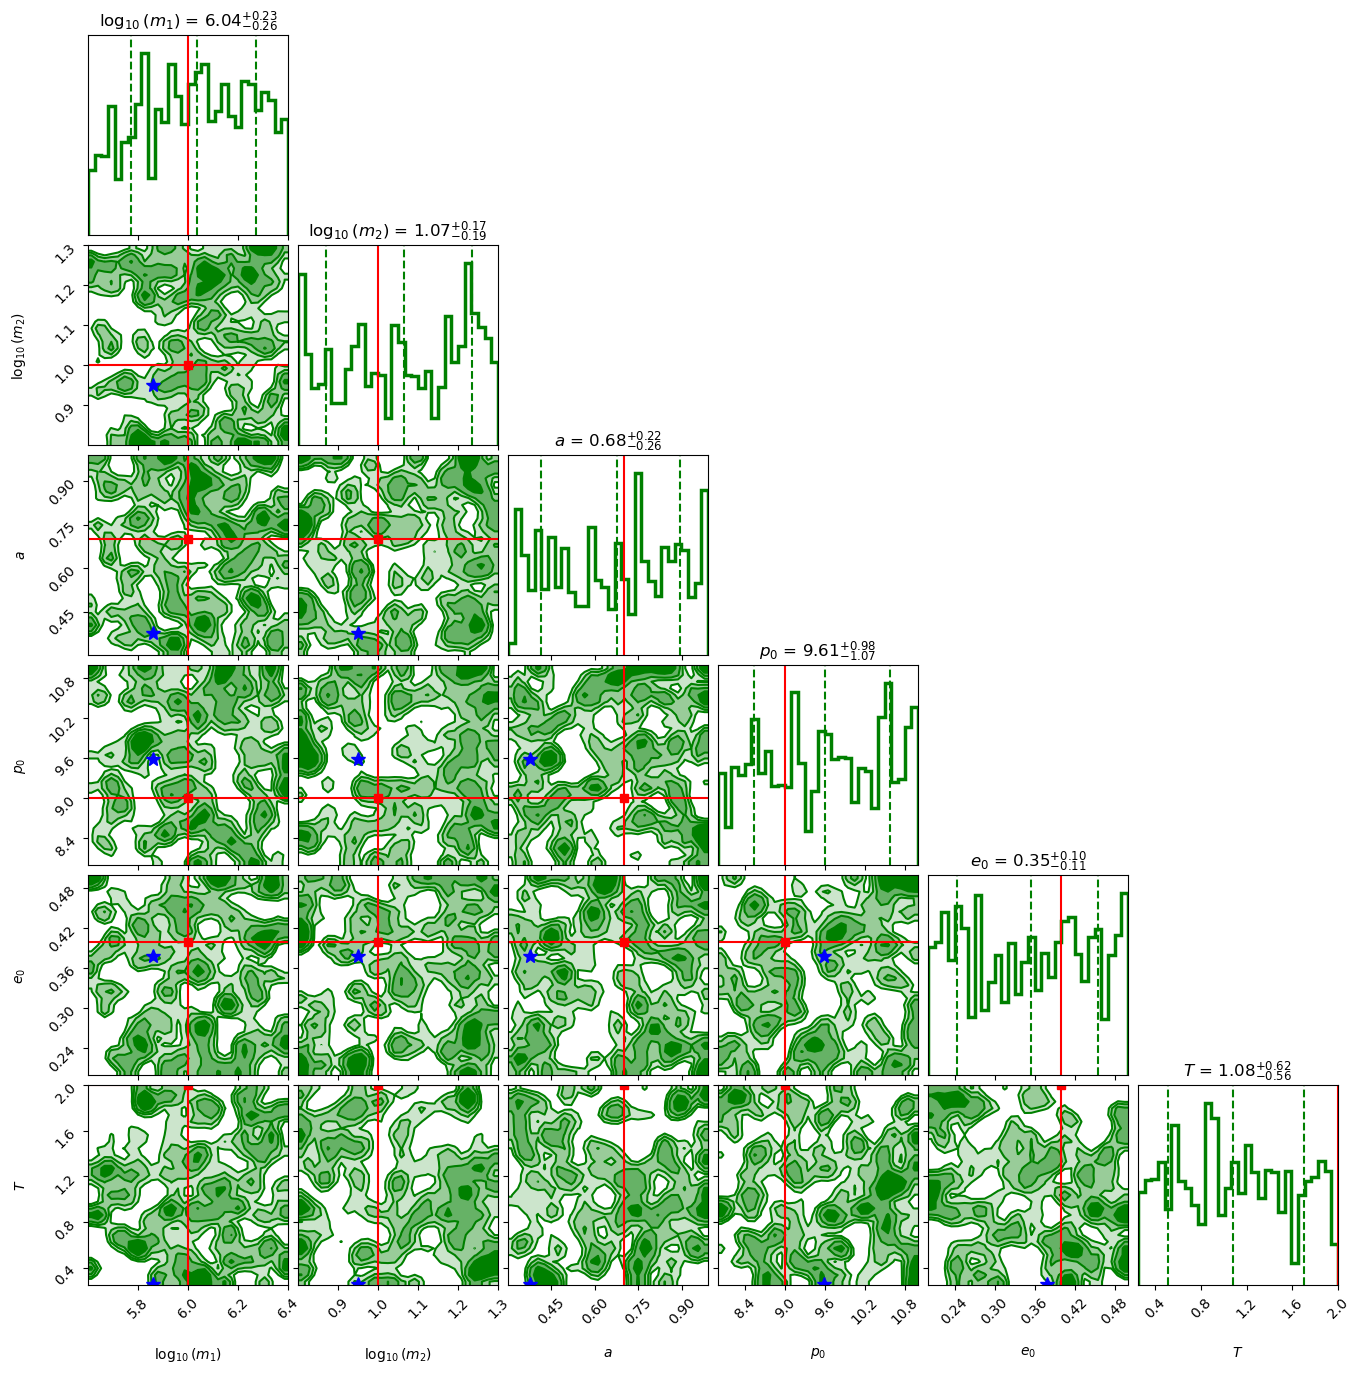

In [13]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [27]:
mask = samples[:, 5] > 1.2  # adjust column index for T
samples_T = samples[mask]
weights_T = weights[mask]
weights_T = weights_T / weights_T.sum()  # renormalize
print(f"Kept {mask.sum()} / {len(mask)} samples")

Kept 2325 / 20000 samples


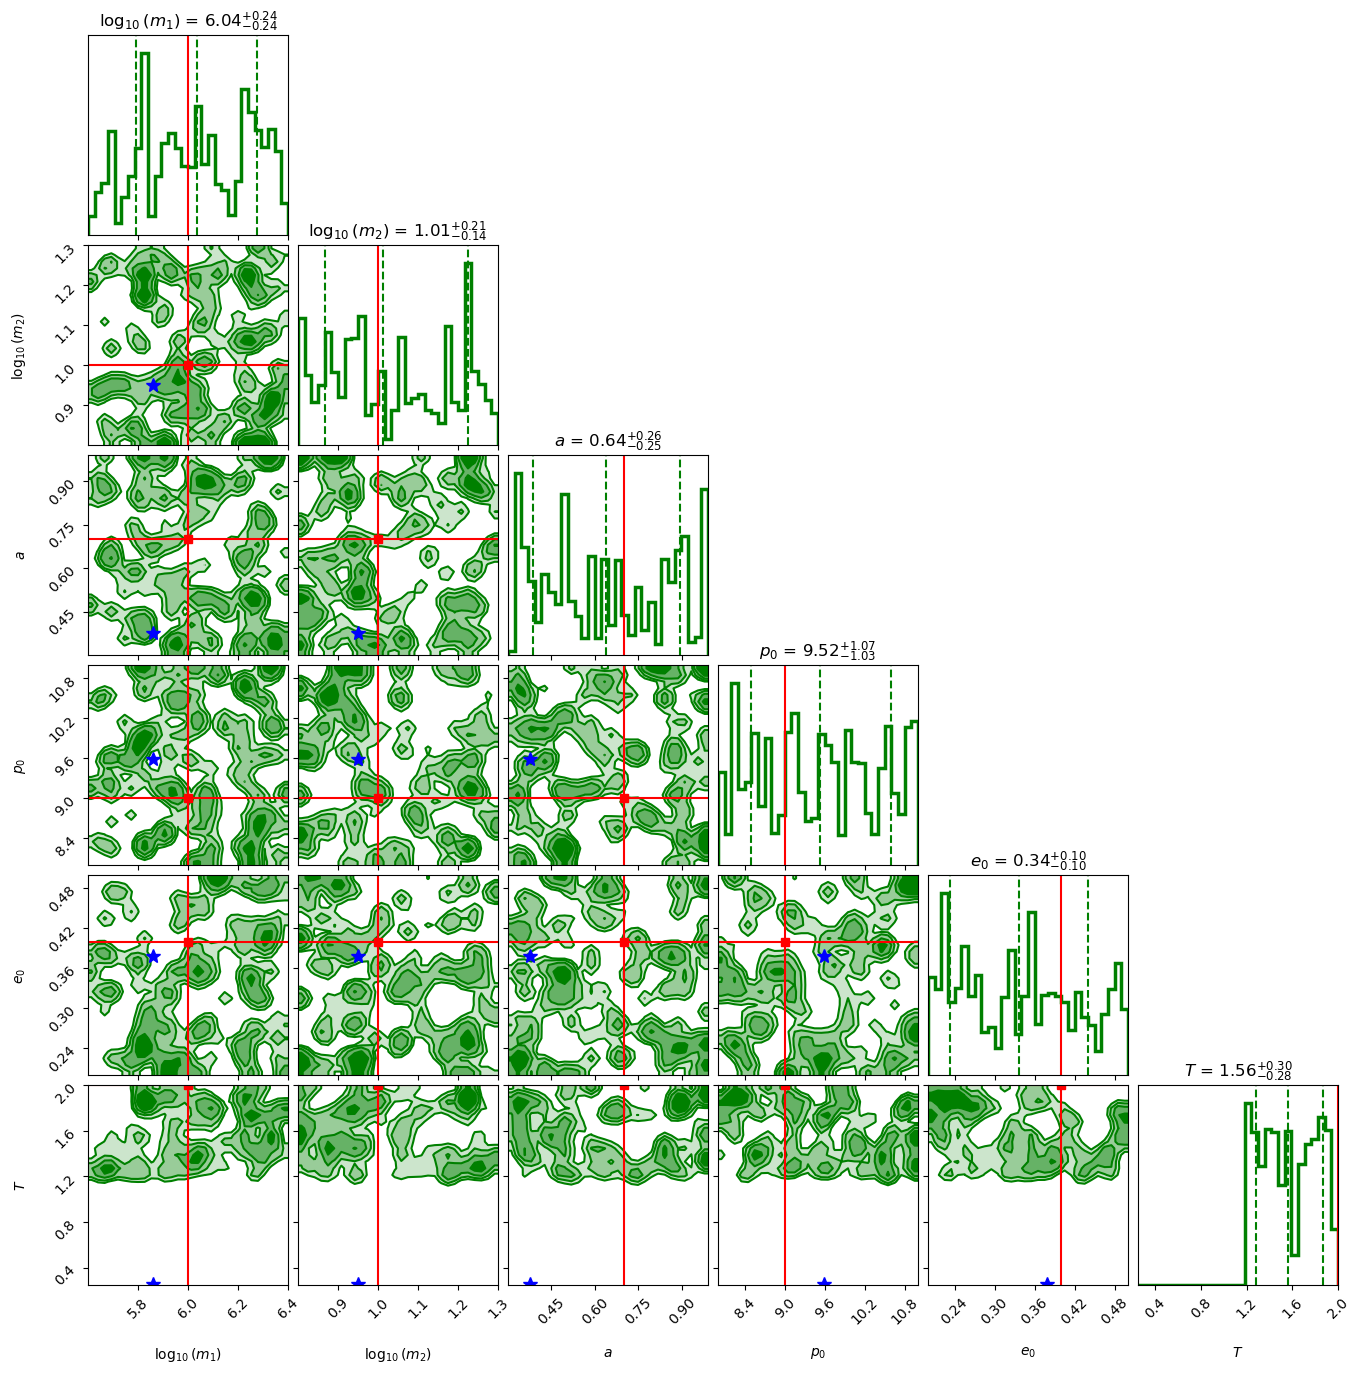

In [28]:
fig = corner.corner(
    samples_T,
    weights=weights_T,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)



# connection plot

In [17]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.86094973, 0.94932914, 0.37423295, 9.58905805, 0.37872334,
        0.26173524]])

In [18]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [19]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [20]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


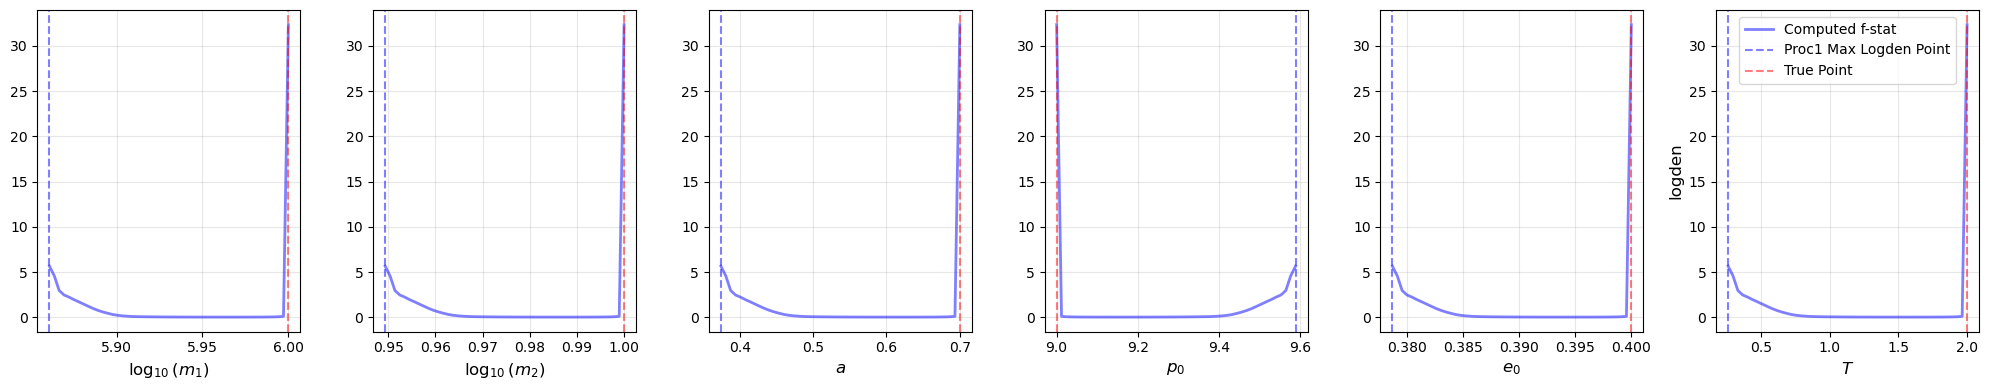

In [21]:
fig_1d, axs_1d = plt.subplots(1, 6, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(6):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [22]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [23]:
t_min, t_max

(np.float64(-0.006751123522450373), np.float64(1.0))

In [24]:
i = 5 #T 
if direction[i] > 0:
    t_lo_dur = (prior_lo[i] - start[i]) / direction[i]
    t_hi_dur = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_dur = (prior_hi[i] - start[i]) / direction[i]
    t_hi_dur = (prior_lo[i] - start[i]) / direction[i]
n_points = 200

t_values_dur = np.linspace(t_lo_dur, t_hi_dur, n_points)
line_points_dur = start[:, np.newaxis] + t_values_dur * direction[:, np.newaxis]





In [25]:
logden_dur=log_density(line_points_dur.T)

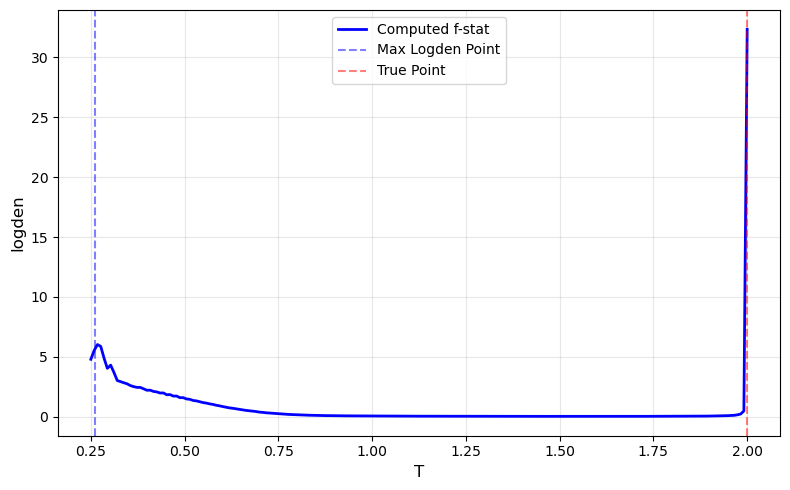

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_dur[i], logden_dur, '-', color='blue', linewidth=2, label='Computed f-stat')
ax.axvline(proc1_maxld_pt_1d[i], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[i],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'T', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()